# Deney Sonuçları ve Değerlendirme

Bu bölümde, Yöntem 1 (RandomFOrest) ve Yöntem 2 (SVM) ve Yöntem (GradiantBoosting) modellerinin eğitim süreçleri, performans metrikleri (Accuracy, Loss, Precision, Recall, F1-Score) ve karmaşıklık matrisleri sunulmaktadır. Ayrıca, gerçek zamanlı demo sırasında elde edilen Kare Başına Saniye (FPS) değerleri de dahil edilmiştir.

### Imports

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import cv2
from pathlib import Path
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

### Tests

Veri seti yükleniyor...
11740 adet örnek yüklendi.
Veri ön işleme tamamlandı.

Modeller yükleniyor...
- SVM yüklendi.
- Random Forest yüklendi.
- XGBoost yüklendi.

Modeller test ediliyor...

--- SVM Modeli Sonuçları ---
              precision    recall  f1-score   support

       angry       0.47      0.49      0.48       303
    confused       0.34      0.29      0.31       244
     disgust       0.40      0.30      0.35       245
        fear       0.66      0.73      0.69       485
       happy       0.68      0.77      0.72       318
     neutral       0.68      0.71      0.69       381
         sad       0.64      0.69      0.66       445
         shy       0.63      0.42      0.50       160
    surprise       0.54      0.53      0.53       354

    accuracy                           0.59      2935
   macro avg       0.56      0.55      0.55      2935
weighted avg       0.58      0.59      0.58      2935



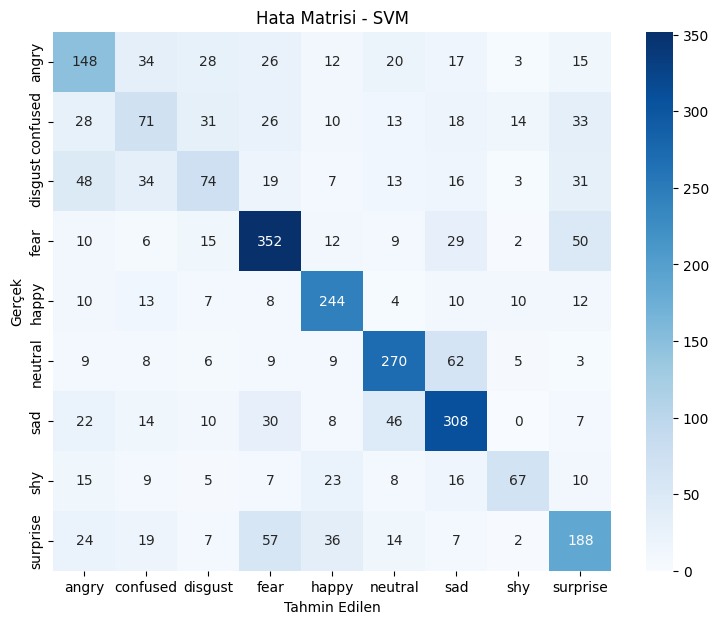


--- Random Forest Modeli Sonuçları ---
              precision    recall  f1-score   support

       angry       0.27      0.17      0.21       303
    confused       0.33      0.04      0.07       244
     disgust       0.14      0.02      0.04       245
        fear       0.57      0.69      0.62       485
       happy       0.73      0.64      0.68       318
     neutral       0.37      0.75      0.49       381
         sad       0.67      0.67      0.67       445
         shy       0.89      0.31      0.46       160
    surprise       0.35      0.53      0.42       354

    accuracy                           0.49      2935
   macro avg       0.48      0.42      0.41      2935
weighted avg       0.48      0.49      0.45      2935



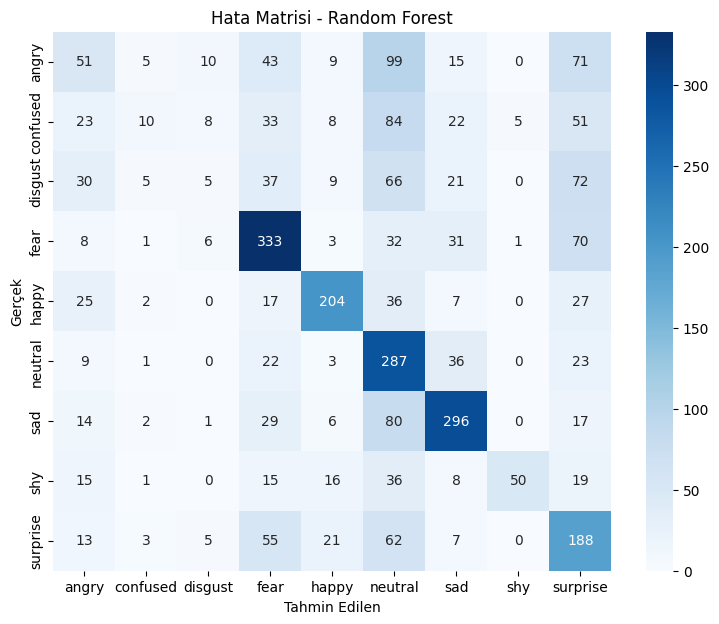


--- XGBoost Modeli Sonuçları ---
              precision    recall  f1-score   support

       angry       0.30      0.36      0.33       303
    confused       0.28      0.23      0.25       244
     disgust       0.29      0.20      0.23       245
        fear       0.74      0.66      0.69       485
       happy       0.63      0.70      0.66       318
     neutral       0.51      0.73      0.60       381
         sad       0.78      0.65      0.71       445
         shy       0.74      0.34      0.46       160
    surprise       0.43      0.53      0.48       354

    accuracy                           0.53      2935
   macro avg       0.52      0.49      0.49      2935
weighted avg       0.55      0.53      0.53      2935



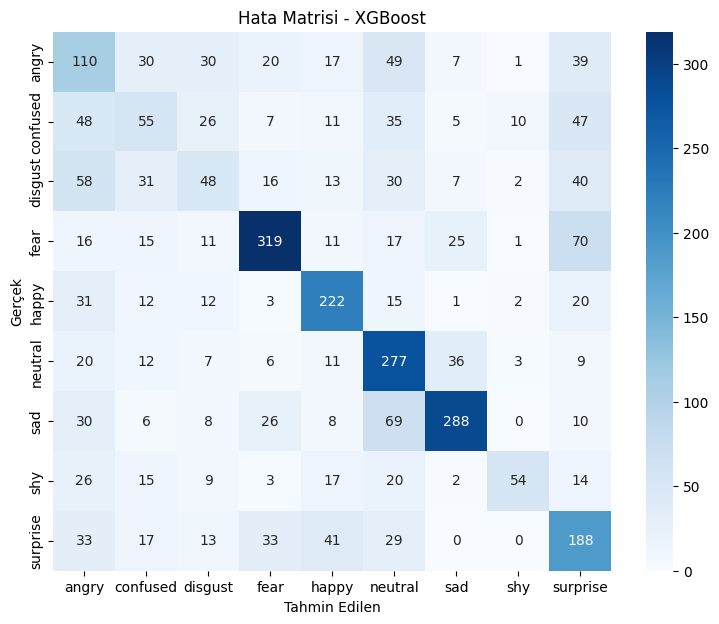


--- Tüm Modellerin Karşılaştırması ---
        Model  Accuracy (%)  Macro F1-Score
          SVM        58.671           0.550
      XGBoost        53.186           0.491
Random Forest        48.518           0.408

En iyi model: SVM


In [3]:
import joblib
import numpy as np
import pandas as pd
import cv2
from pathlib import Path
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Yolları ve sabitleri tanımla
BASE_DIR = Path().resolve()
PROCESSED_DATASET_PATH = BASE_DIR / 'processed_dataset_gray'
IMG_SIZE = (128, 128)

# Resimlerden HOG özelliklerini çıkar
features_list = []
labels_list = []

if not PROCESSED_DATASET_PATH.exists():
    raise FileNotFoundError(f"Hata: '{PROCESSED_DATASET_PATH}' klasörü bulunamadı.")

print("Veri seti yükleniyor...")
CLASS_NAMES = sorted([d.name for d in PROCESSED_DATASET_PATH.iterdir() if d.is_dir()])
for class_name in CLASS_NAMES:
    class_path = PROCESSED_DATASET_PATH / class_name
    for img_path in sorted(list(class_path.glob('*.png'))):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None and img.shape == IMG_SIZE:
            hog_features = hog(img, orientations=9, pixels_per_cell=(8, 8),
                               cells_per_block=(2, 2), visualize=False, block_norm='L2-Hys')
            features_list.append(hog_features)
            labels_list.append(class_name)

X = np.array(features_list)
y = np.array(labels_list)
print(f"{X.shape[0]} adet örnek yüklendi.")

# Veriyi train/test olarak böl
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, shuffle=True, random_state=42, stratify=y
)

# Veriyi ölçekle ve PCA uygula
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Etiketleri kodla
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
print("Veri ön işleme tamamlandı.\n")

# Kaydedilmiş modelleri yükle
models_to_evaluate = {}
model_files_to_load = {
    "SVM": 'best_svm_model.joblib',
    "Random Forest": 'best_rf_model.joblib',
    "XGBoost": 'best_xgb_model.joblib'
}

print("Modeller yükleniyor...")
for model_name, filename in model_files_to_load.items():
    if Path(filename).exists():
        models_to_evaluate[model_name] = joblib.load(filename)
        print(f"- {model_name} yüklendi.")
    else:
        print(f"- Uyarı: '{filename}' bulunamadı.")

# Modelleri değerlendir
if not models_to_evaluate:
    print("\nDeğerlendirilecek model bulunamadı.")
else:
    all_results = []
    print("\nModeller test ediliyor...")
    
    for model_name, model in models_to_evaluate.items():
        print(f"\n--- {model_name} Modeli Sonuçları ---")
        
        y_pred = model.predict(X_test_pca)
        
        # XGBoost sayısal dönebilir, metne çevir
        try:
            int(y_pred[0])
            y_pred_text = le.inverse_transform(y_pred)
        except (ValueError, TypeError):
            y_pred_text = y_pred

        y_true_text = y_test
        
        print(classification_report(y_true_text, y_pred_text, target_names=CLASS_NAMES))

        report_dict = classification_report(y_true_text, y_pred_text, output_dict=True)
        all_results.append({
            "Model": model_name,
            "Accuracy (%)": report_dict['accuracy'] * 100,
            "Macro F1-Score": report_dict['macro avg']['f1-score']
        })
        
        # Hata matrisini çiz
        cm = confusion_matrix(y_true_text, y_pred_text, labels=CLASS_NAMES)
        plt.figure(figsize=(9, 7))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        plt.title(f'Hata Matrisi - {model_name}')
        plt.xlabel('Tahmin Edilen')
        plt.ylabel('Gerçek')
        plt.show()

    # Tüm sonuçları karşılaştır
    print("\n--- Tüm Modellerin Karşılaştırması ---")
    df_final = pd.DataFrame(all_results).sort_values(by="Macro F1-Score", ascending=False)
    print(df_final.round(3).to_string(index=False))

    best_model_name = df_final.iloc[0]['Model']
    print(f"\nEn iyi model: {best_model_name}")

### Camera Test

In [2]:
# =============================================================================
# BÖLÜM: GERÇEK ZAMANLI KAMERA TESTİ (BAĞIMSIZ VE DÜZELTİLMİŞ)
# =============================================================================
# Bu script, daha önce kaydedilmiş modelleri ve veri işleme araçlarını
# diskten yükleyerek, önceki hücrelere bağımlı olmadan çalışır.

import cv2
import dlib
import joblib
import numpy as np
from pathlib import Path
from skimage.feature import hog

print("\n" + "="*80)
print("Gerçek Zamanlı Kamera Testi Başlatılıyor...")
print("="*80)

# --- 1. Gerekli Dosyaları Yükleme ---
print("Gerekli model ve araçlar diskten yükleniyor...")

# Ayarlar
MODEL_FILENAME = 'best_xgb_model.joblib'
SCALER_FILENAME = 'scaler.joblib'
PCA_FILENAME = 'pca.joblib'
LABEL_ENCODER_FILENAME = 'label_encoder.joblib'
OPTIMAL_SIZE = 128

try:
    model_to_test = joblib.load(MODEL_FILENAME)
    scaler = joblib.load(SCALER_FILENAME)
    pca = joblib.load(PCA_FILENAME)
    le = joblib.load(LABEL_ENCODER_FILENAME)
    face_detector = dlib.get_frontal_face_detector()
    
    model_name_to_test = Path(MODEL_FILENAME).stem 
    print(f"-> Model ('{model_name_to_test}') ve tüm araçlar başarıyla yüklendi.")
    print(f"-> Model, {pca.n_components_} öznitelik bekliyor.")
    is_ready = True
except FileNotFoundError as e:
    print(f"\nHATA: Gerekli bir dosya bulunamadı: {e.filename}")
    print("Lütfen eğitim script'ini çalıştırdığınızdan ve tüm .joblib dosyalarının")
    print("bu script ile aynı klasörde olduğundan emin olun.")
    is_ready = False

# --- 2. Kamera Döngüsünü Başlatma ---
if is_ready:
    is_xgb = "xgb" in model_name_to_test.lower()
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("HATA: Web kamerası başlatılamadı.")
    else:
        print("\n>>> Web kamerası başlatıldı. Çıkmak için 'q' tuşuna basın. <<<")
        
        # Döngüyü kırmak için bir bayrak değişkeni
        exit_flag = False
        
        while not exit_flag:
            ret, frame = cap.read()
            if not ret: 
                break
                
            gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            rects = face_detector(gray_frame, 0)
            
            for rect in rects:
                x1, y1, x2, y2 = rect.left(), rect.top(), rect.right(), rect.bottom()
                
                w, h = x2 - x1, y2 - y1
                cx, cy = x1 + w // 2, y1 + h // 2
                new_w, new_h = int(w * 1.5), int(h * 1.5)
                nx1, ny1 = max(cx - new_w // 2, 0), max(cy - new_h // 2, 0)
                nx2, ny2 = min(cx + new_w // 2, frame.shape[1]), min(cy + new_h // 2, frame.shape[0])
                face_crop = frame[ny1:ny2, nx1:nx2]
                
                if face_crop.size > 0:
                    img_yuv = cv2.cvtColor(face_crop, cv2.COLOR_BGR2YUV)
                    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
                    img_yuv[:, :, 0] = clahe.apply(img_yuv[:, :, 0])
                    face_crop_clahe = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

                    scale = OPTIMAL_SIZE / max(face_crop_clahe.shape[:2])
                    resized = cv2.resize(face_crop_clahe, (int(face_crop_clahe.shape[1] * scale), int(face_crop_clahe.shape[0] * scale)))
                    final_img = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
                    canvas = np.zeros((OPTIMAL_SIZE, OPTIMAL_SIZE), dtype=np.uint8)
                    y_off, x_off = (OPTIMAL_SIZE - final_img.shape[0]) // 2, (OPTIMAL_SIZE - final_img.shape[1]) // 2
                    canvas[y_off:y_off + final_img.shape[0], x_off:x_off + final_img.shape[1]] = final_img
                    
                    hog_features = hog(canvas, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=False)
                    hog_features_scaled = scaler.transform(hog_features.reshape(1, -1))
                    hog_features_pca = pca.transform(hog_features_scaled)
                    
                    prediction = model_to_test.predict(hog_features_pca)
                    
                    if hasattr(model_to_test, "predict_proba"):
                        prediction_proba = model_to_test.predict_proba(hog_features_pca)
                        confidence = np.max(prediction_proba) * 100
                        prediction_text = le.inverse_transform(prediction)[0] if is_xgb else prediction[0]
                        text_to_display = f"{prediction_text} ({confidence:.1f}%)"
                    else:
                        prediction_text = le.inverse_transform(prediction)[0] if is_xgb else prediction[0]
                        text_to_display = prediction_text
                    
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(frame, text_to_display, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (36, 255, 12), 2)

            cv2.imshow("Gercek Zamanli Duygu Tanima", frame)
            
            # Tuşa basılmasını bekle
            key = cv2.waitKey(1) & 0xFF
            if key == ord('q'):
                exit_flag = True # Bayrağı True yap
        
        # Temizlik
        cap.release()
        cv2.destroyAllWindows()
        print("\nKamera kapatıldı.")


Gerçek Zamanlı Kamera Testi Başlatılıyor...
Gerekli model ve araçlar diskten yükleniyor...

HATA: Gerekli bir dosya bulunamadı: scaler.joblib
Lütfen eğitim script'ini çalıştırdığınızdan ve tüm .joblib dosyalarının
bu script ile aynı klasörde olduğundan emin olun.
